## Библиотеки

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import RegressorChain
from sklearn.model_selection import GridSearchCV, train_test_split
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score

## Анализ данных температур

<img src="../images/temp_zone.jpg" alt="temperature zone" style="max-width:800px">
<img src="../images/shem_temp_zone.jpg" alt="shem temperature zone" style="max-width:800px">

In [2]:
df = pd.read_excel("1temperature_data_recovery/data/clarified_dataset.xlsx")

In [3]:
HEALTH_STATUS_COLUMN = 'th_cls_breast'
BREAST_SIDE = 'breast'

right_temp_df = df[(df[HEALTH_STATUS_COLUMN] == 0) & (df[BREAST_SIDE] == 'r')]
left_temp_df = df[(df[HEALTH_STATUS_COLUMN] == 0) & (df[BREAST_SIDE] == 'l')]

x_cols = [f'ir_{i}' for i in range(0, 9)] # кожные температуры
y_cols = [f'mw_{i}' for i in range(0, 9)] # глубинные температуры
use_cols = x_cols + y_cols

temperature_df = df.loc[:, use_cols]
right_temp_df = right_temp_df.loc[:,  use_cols]
left_temp_df = left_temp_df.loc[:,  use_cols]

## Первичный анализ данных

Базовые параметры кожных температур:

In [4]:
temperature_df.loc[:, x_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ir_0,9162.0,33.050371,1.284449,25.2,32.4,33.2,33.9,36.9
ir_1,9162.0,33.221873,1.134680,27.8,32.6,33.4,34.0,36.2
ir_2,9162.0,33.243451,1.111068,26.7,32.6,33.4,34.0,36.0
ir_3,9162.0,33.160904,1.127247,27.7,32.5,33.3,33.9,36.1
ir_4,9162.0,33.042960,1.061980,27.6,32.4,33.2,33.8,36.2
ir_5,9162.0,32.828564,1.084798,27.2,32.2,32.9,33.6,36.0
ir_6,9162.0,32.476992,1.197549,27.3,31.7,32.6,33.3,35.7
ir_7,9162.0,32.591847,1.188675,27.1,31.9,32.7,33.4,35.7
ir_8,9162.0,32.953362,1.128646,27.9,32.3,33.1,33.7,36.2


Базовые параметры внутренних температур:

In [5]:
temperature_df.loc[:, y_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mw_0,9162.0,34.907880,1.158463,28.0,34.3,35.1,35.7,37.4
mw_1,9162.0,35.046191,0.934144,29.2,34.6,35.2,35.7,37.5
mw_2,9162.0,35.155927,0.903005,29.1,34.7,35.3,35.8,37.3
mw_3,9162.0,35.070138,0.932060,30.2,34.6,35.2,35.7,37.3
mw_4,9162.0,34.943189,0.885102,30.3,34.5,35.1,35.6,37.4
mw_5,9162.0,34.794968,0.916795,30.1,34.3,34.9,35.4,37.3
mw_6,9162.0,34.578651,1.008297,29.4,34.0,34.7,35.3,37.0
mw_7,9162.0,34.688147,1.005841,29.4,34.1,34.8,35.4,37.3
mw_8,9162.0,34.926828,0.964052,29.5,34.4,35.1,35.6,37.4


Поиск пропусков и общая информация о датасете:

In [50]:
temperature_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5744 entries, 0 to 9067
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ir_0    5744 non-null   float64
 1   ir_1    5744 non-null   float64
 2   ir_2    5744 non-null   float64
 3   ir_3    5744 non-null   float64
 4   ir_4    5744 non-null   float64
 5   ir_5    5744 non-null   float64
 6   ir_6    5744 non-null   float64
 7   ir_7    5744 non-null   float64
 8   ir_8    5744 non-null   float64
 9   mw_0    5744 non-null   float64
 10  mw_1    5744 non-null   float64
 11  mw_2    5744 non-null   float64
 12  mw_3    5744 non-null   float64
 13  mw_4    5744 non-null   float64
 14  mw_5    5744 non-null   float64
 15  mw_6    5744 non-null   float64
 16  mw_7    5744 non-null   float64
 17  mw_8    5744 non-null   float64
dtypes: float64(18)
memory usage: 852.6 KB


Поиск дубликатов:

In [6]:
temperature_df[temperature_df.duplicated()]

,ir_0,ir_1,ir_2,ir_3,ir_4,ir_5,ir_6,ir_7,ir_8,mw_0,mw_1,mw_2,mw_3,mw_4,mw_5,mw_6,mw_7,mw_8
754,32.9,33.2,33.4,34.7,33.5,33.4,32.9,33.0,32.8,35.2,34.7,35.4,35.8,35.5,35.3,35.0,34.9,34.6
1064,35.5,35.5,35.2,34.8,34.6,35.0,34.7,34.9,34.7,36.3,36.0,36.0,35.9,35.3,35.8,35.6,36.0,35.9
1476,31.4,31.8,32.3,33.0,33.0,31.5,28.8,29.8,31.0,33.3,33.3,34.7,34.9,35.0,34.0,31.2,31.7,32.6
1662,33.0,33.2,32.8,32.8,33.1,33.0,32.4,32.9,33.9,34.8,35.1,34.8,34.9,34.8,34.7,34.1,34.7,35.0
2962,33.8,34.4,32.7,33.7,34.0,34.1,32.6,33.3,33.4,35.6,36.5,35.1,35.5,35.9,35.6,35.1,35.4,35.4
3092,33.2,33.3,33.5,33.0,32.8,32.5,32.0,33.1,33.0,35.4,35.5,35.7,35.3,35.0,34.6,34.3,35.0,35.3
5220,32.7,33.5,33.8,33.7,34.2,34.0,33.3,32.2,33.8,34.9,35.2,35.7,35.6,36.0,35.6,34.8,34.4,35.2
6007,31.5,32.6,33.0,32.9,33.3,32.7,32.4,31.1,31.4,33.6,34.3,35.3,35.1,35.4,35.3,34.4,33.4,33.7
6208,32.5,32.8,32.4,33.2,33.4,33.3,32.5,32.1,33.5,34.3,34.4,34.3,34.6,35.2,34.6,34.1,34.3,35.1
6476,31.6,31.4,31.7,31.1,30.7,30.4,31.3,30.9,31.1,34.2,34.1,34.8,34.6,34.2,34.0,34.5,34.6,34.5


In [7]:
temperature_df.drop_duplicates(inplace=True)

Построение корреляционной матрицы:

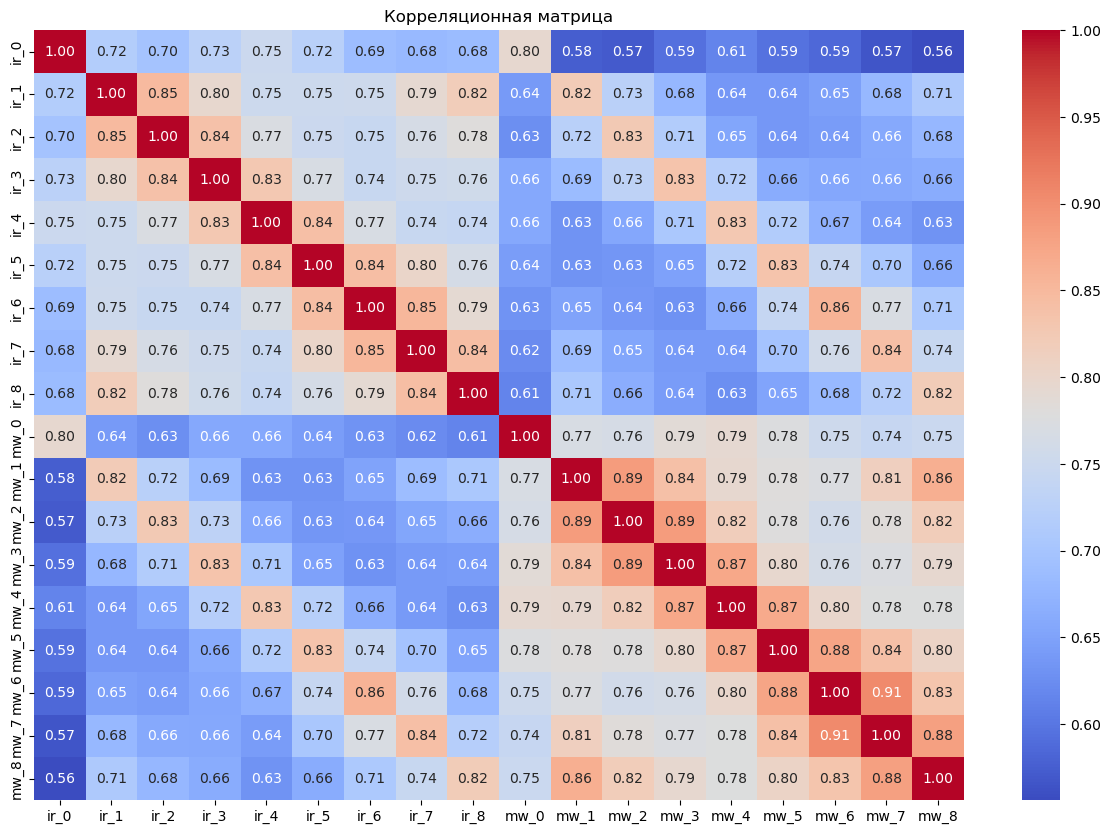

In [5]:
corr_matrix = temperature_df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

## Создание новых признаков

"Раздуем" обучающие данные, добавив квадрат, корень, среднее значение, разброс температур:

In [13]:
cols_funcs = {
    "pow_2": lambda x: np.pow(x, 2),
    'exp': lambda x: np.exp(-x),
    'coefficient_1.5': lambda x: 1.5 * x,
    'sin': lambda x: np.sin(x),
}

rows_funcs = {
    "max-min": lambda x: x.max(axis=1) - x.min(axis=1),
}

generated_feature_x = []

for key, func in cols_funcs.items():
    for col in x_cols:
        name_new_col = f'{col}_{key}'
        temperature_df[name_new_col] = func(temperature_df[col])
        generated_feature_x.append(name_new_col)


for key, func in rows_funcs.items():
    temperature_df[key] = func(temperature_df[x_cols])
    generated_feature_x.append(key)

Корреляция только между сгенерированными признаками:

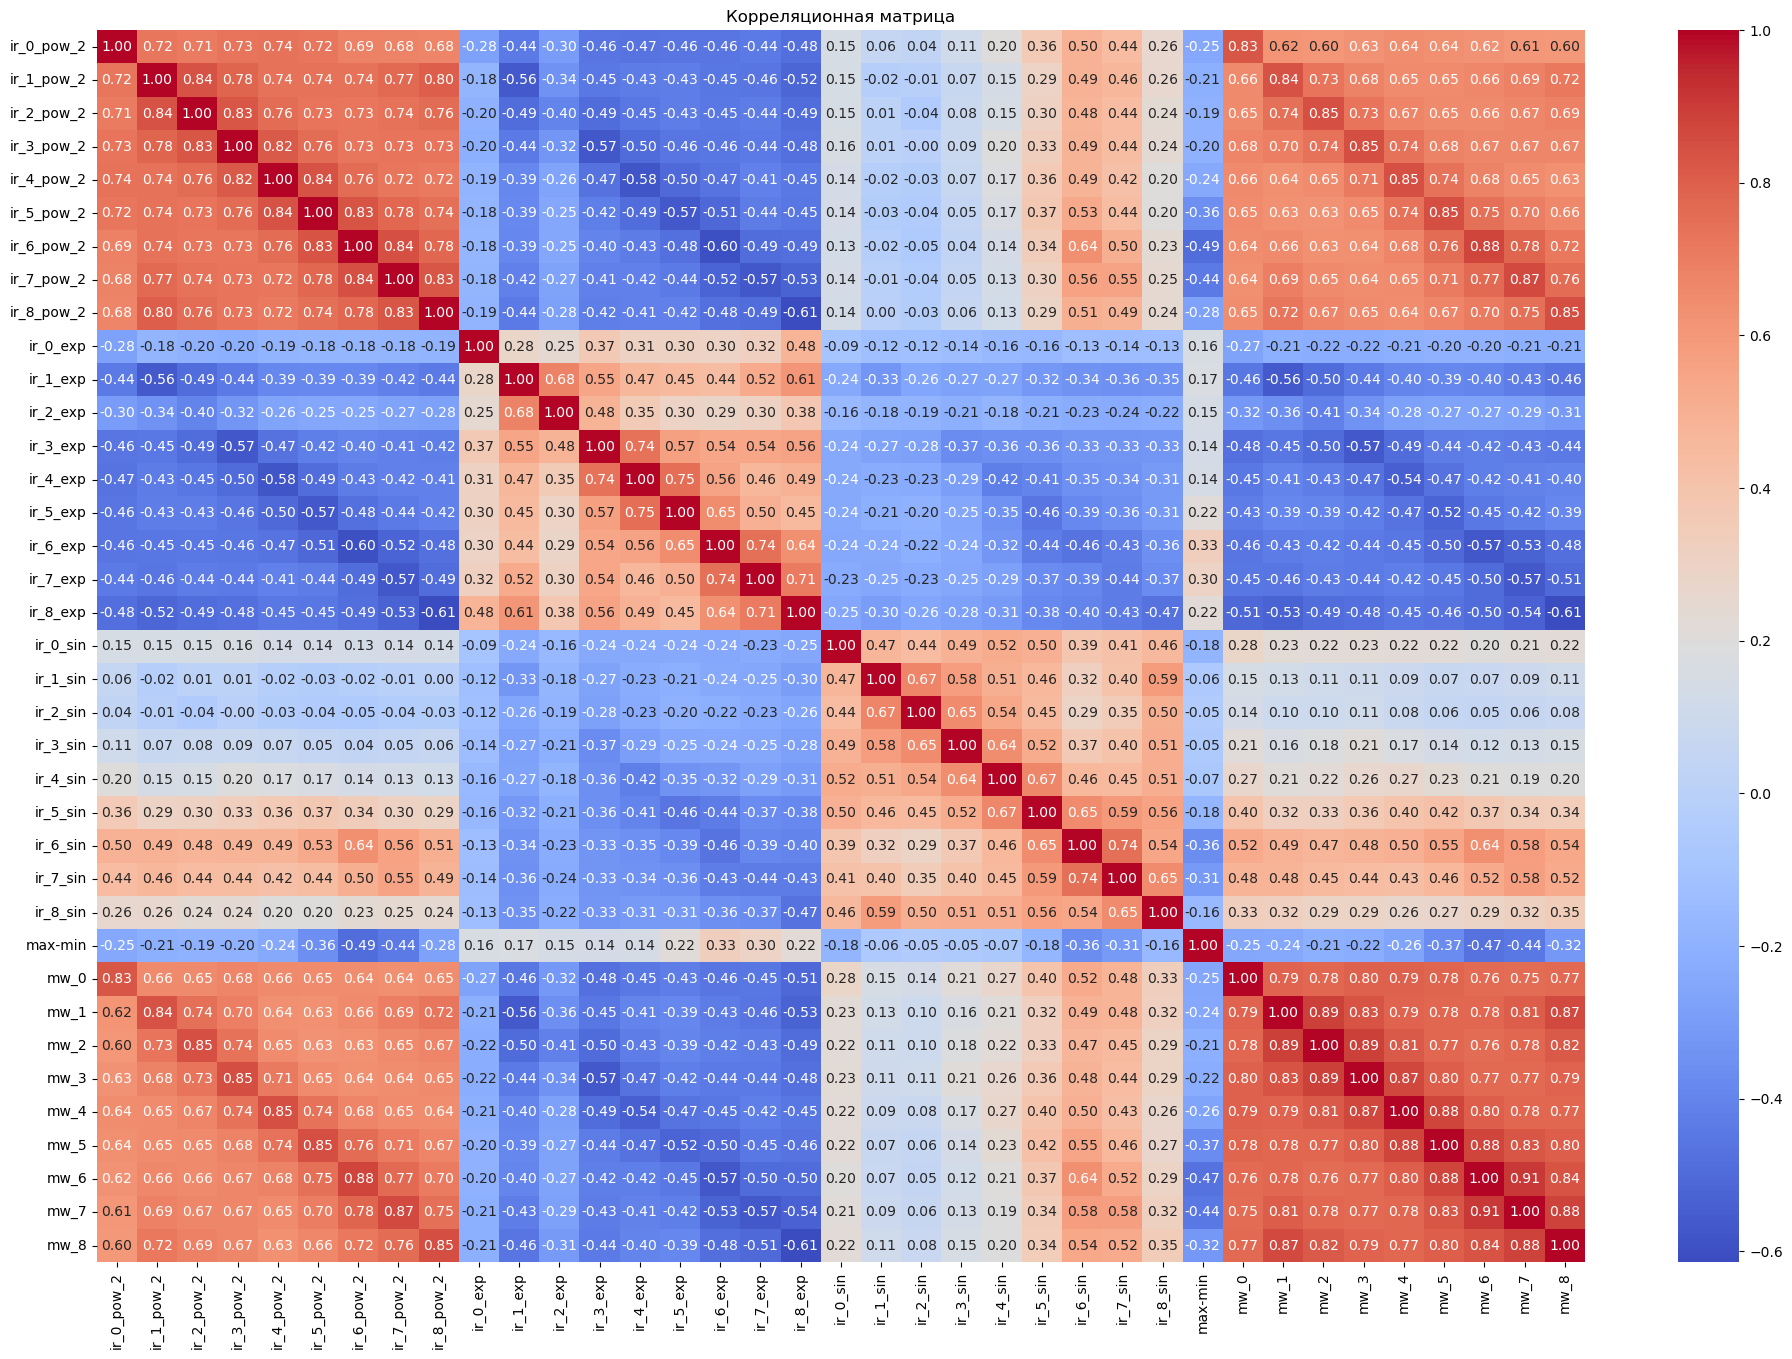

In [16]:
corr_matrix = temperature_df[generated_feature_x + y_cols].corr()
plt.figure(figsize=(24, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

## Аппроксимация

`Посмотрим на распределение целевых переменных:`

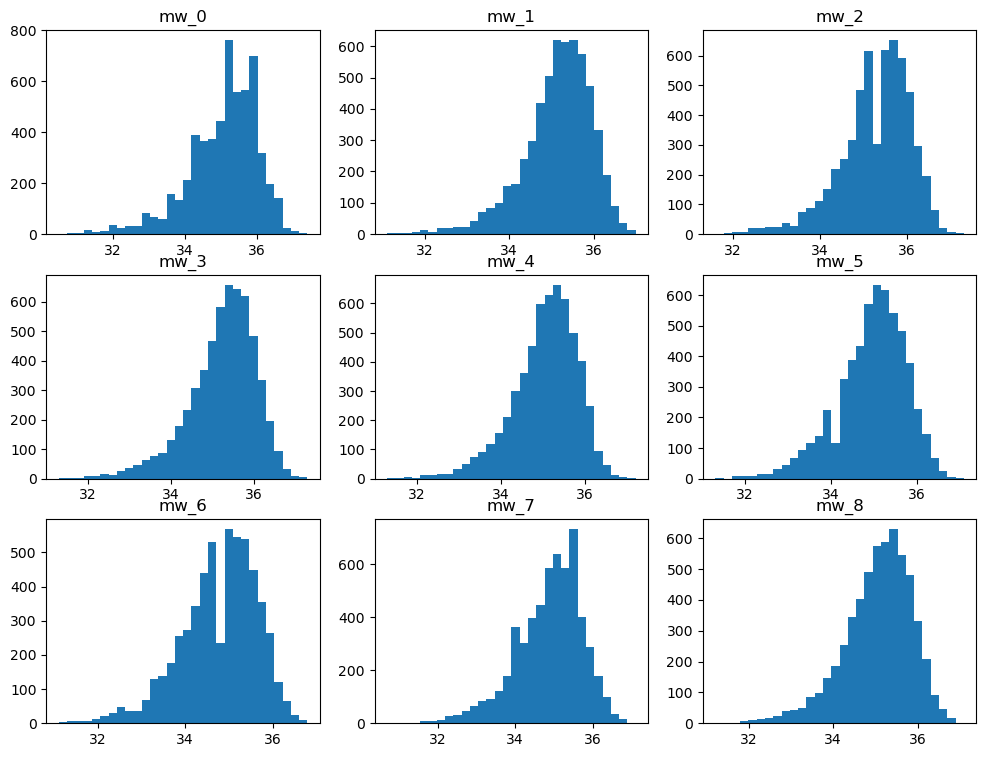

In [31]:
figure, axes = plt.subplots(ncols=3, nrows=3, figsize=(12, 9))
axes = axes.ravel()

for ax, target in zip(axes, y_cols):
    ax.hist(temperature_df[target], bins=30)
    ax.set_title(f'{target}')

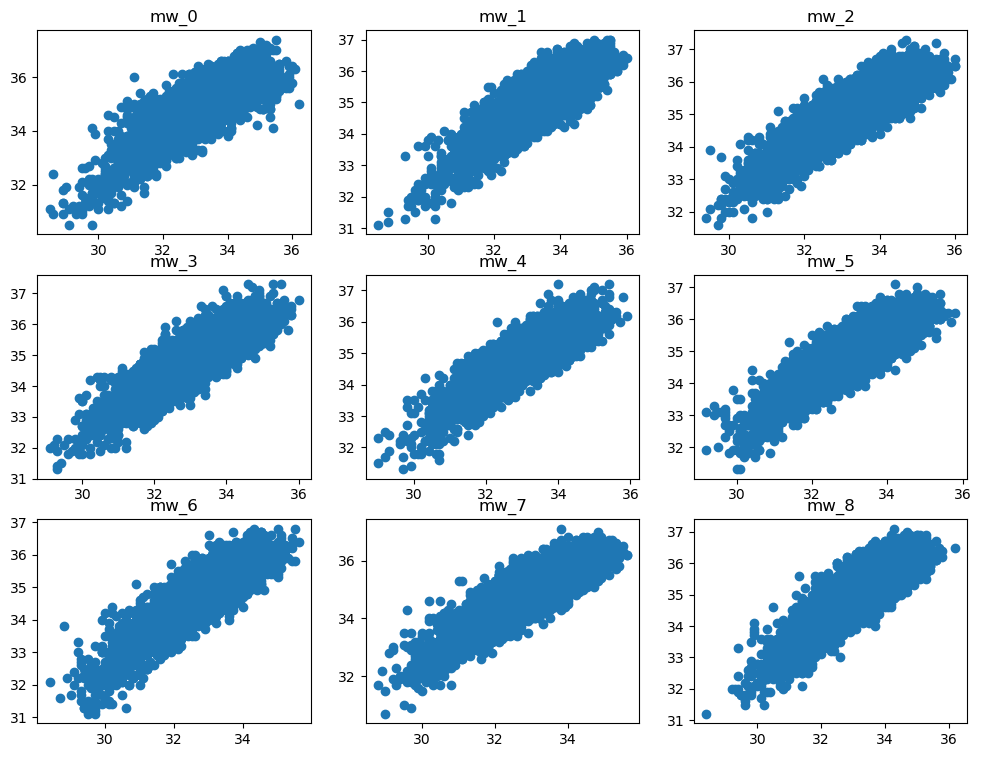

In [18]:
figure, axes = plt.subplots(ncols=3, nrows=3, figsize=(12, 9))
axes = axes.ravel()

for ax, y, x in zip(axes, y_cols, x_cols):
    ax.scatter(temperature_df[x], temperature_df[y])
    ax.set_title(f'{y}')

Распределения случайных величин похоже на: `нормальное распределение со сдвигом вправо`, `распределение Фишера (F-распределение)`, `Распределение Вейбулла`.

In [9]:
class MinMaxNormalize:
    def __init__(self, values_start):
        self.values_start = values_start
        self.max_value = np.max(self.values_start)
        self.min_value = np.min(self.values_start)

    def normalize(self):
        values_normalize = (self.values_start - self.min_value) / (self.max_value - self.min_value)
        
        return values_normalize
    
    def denormalize(self, values_normalize):
        return values_normalize * (self.max_value - self.min_value) + self.min_value

def lognormal_distribution(X, coef_lognormal_peak, sigma, mu, free_term):

    '''(1 логнорм распредел со свободным коэффициентом)'''

    numerator = np.exp(-(np.log(X) - mu)**2 / (2 * sigma**2))
    denominator = X * sigma * np.sqrt(2 * np.pi)

    lognorm_distrib = coef_lognormal_peak * numerator / denominator

    return lognorm_distrib + free_term

In [10]:
def search_specific_name_cols(postfix:str):
    specific_name_cols = []
    for name_col in generated_feature_x:
        if postfix in name_col:
            specific_name_cols.append(name_col)

    return specific_name_cols

Агрегируем значения X в среднее значение и подберём оптимальные коэффициенты для нормального распределения с помощью МНК:

{'mw_0': array([ 4.83087355, -0.09461117,  3.39383432,  0.90275834]),
 'mw_1': array([ 6.21559535, -0.12045885,  3.37832186,  0.92959049]),
 'mw_2': array([ 7.71807022, -0.13650474,  3.35202229,  0.97518373]),
 'mw_3': array([ 7.5103421 , -0.12060212,  3.36978791,  0.93381591]),
 'mw_4': array([ 8.58741066, -0.13786946,  3.36271934,  0.94902946]),
 'mw_5': array([ 8.72248021, -0.14051249,  3.37834   ,  0.99999219]),
 'mw_6': array([ 8.13973508, -0.13230729,  3.39116365,  1.03719907]),
 'mw_7': array([ 8.94236097, -0.14115104,  3.37131172,  1.00786602]),
 'mw_8': array([ 6.63187329, -0.12010433,  3.38325943,  0.94108388])}

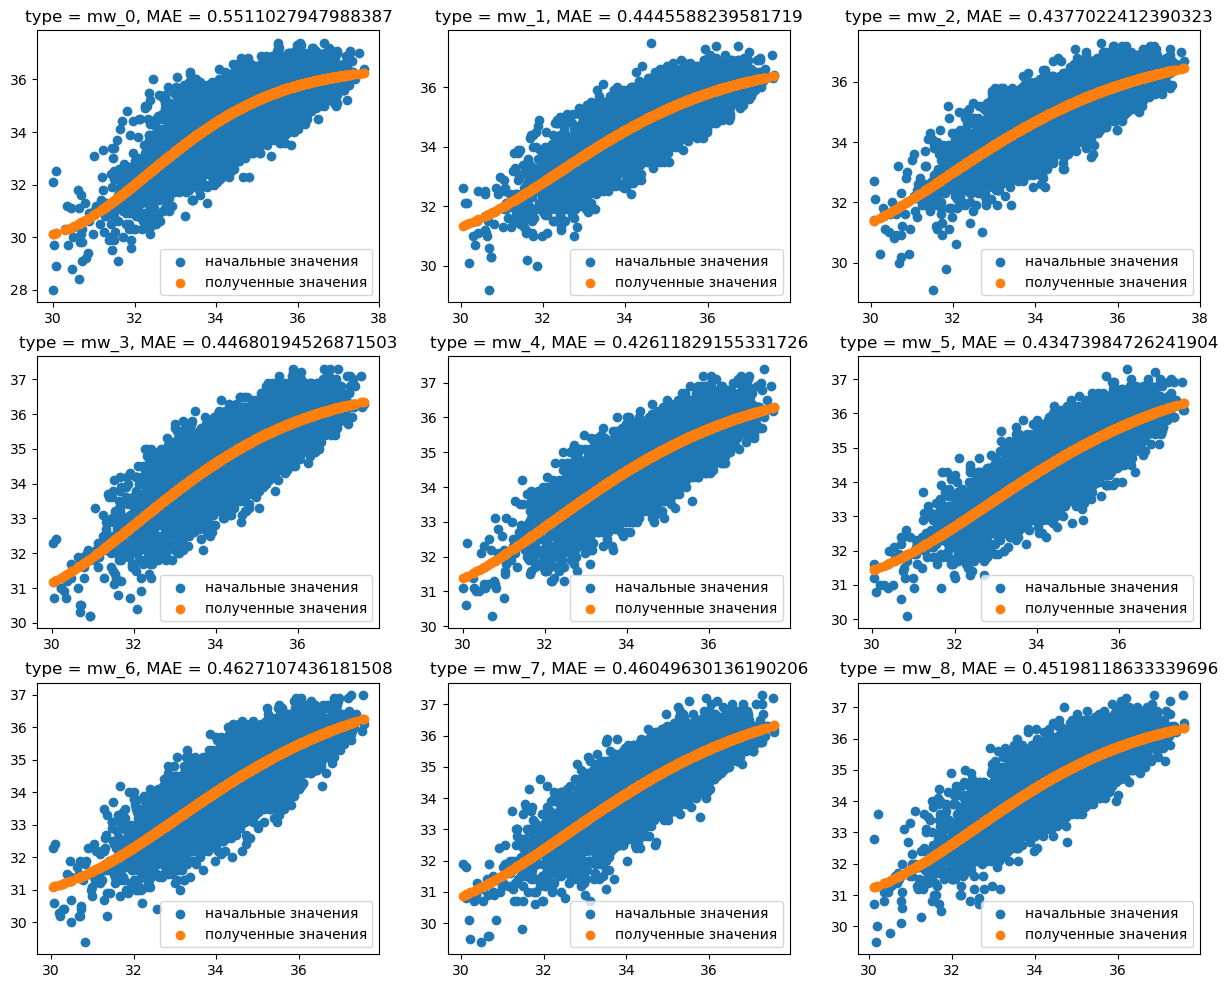

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

init_params = [1, 0.9, 0.5, 0.5]
popt_values = dict()

specific_cols = search_specific_name_cols('coefficient_1.5')
mix_x_cols = x_cols.copy()


for i, (ax, y, x_sp) in enumerate(zip(axes, y_cols, specific_cols)):
    mix_x_cols[i] = x_sp
    agr_X = temperature_df[mix_x_cols].mean(axis=1)
    y_start = temperature_df[y].to_numpy()

    normalize_obj = MinMaxNormalize(y_start)
    y_normilize = normalize_obj.normalize()

    popt, pcov = curve_fit(lognormal_distribution, agr_X, y_normilize, method='trf', p0=init_params)
    popt_values[y] = popt

    y_predicts = lognormal_distribution(agr_X, *popt)
    y_predicts_denormilize = normalize_obj.denormalize(y_predicts)
    error_mae = mean_absolute_error(y_start, y_predicts_denormilize)

    ax.scatter(agr_X, y_start, label='начальные значения')
    ax.scatter(agr_X, y_predicts_denormilize, label='полученные значения')
    ax.set_title(f'type = {y}, MAE = {error_mae}')
    ax.legend()

    mix_x_cols = x_cols.copy()

popt_values

## Применение линейной регрессии

In [6]:
new_and_old_xcols = x_cols + generated_feature_x

`Линейная регрессия с применением стандартизации данных:`

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

line_reg_pipline = make_pipeline(
    StandardScaler(),
    LinearRegression(n_jobs=-1)
)

line_reg_pipline.fit(X_train, y_train)

y_pred = line_reg_pipline.predict(X_test)

error_mae = mean_absolute_error(y_pred, y_test)
print(error_mae)

0.37322717675168526


`Полиномиальная регрессия:`

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

poly_features_pipline = make_pipeline(
    PolynomialFeatures(degree=2),
    StandardScaler(),
    LinearRegression(n_jobs=-1)
)

poly_features_pipline.fit(X_train, y_train)
pred = poly_features_pipline.predict(X_test)
print(mean_absolute_error(y_test, pred))

0.4447707915760406


`Lasso:`

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

model = Lasso(alpha=0.0001, max_iter=1000)

lasso_pipline = make_pipeline(
    StandardScaler(),
    model
)

lasso_pipline.fit(X_train, y_train)

y_pred = lasso_pipline.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.37320262160887463


Redge

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

ridge_pipline = make_pipeline(
    StandardScaler(),
    Ridge(alpha=0.07)
)

ridge_pipline.fit(X_train, y_train)

y_pred = ridge_pipline.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.37322716907461523


`ElasticNet`

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

elastic_net_pipline = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=0.0001, l1_ratio=0.01)
)

elastic_net_pipline.fit(X_train, y_train)

y_pred = elastic_net_pipline.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.3732268740139053


`Модель цепочной линейной регрессии:`

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

model = LinearRegression()
chain = RegressorChain(model)

line_reg_chain_pipline = make_pipeline(
    StandardScaler(),
    chain
)

line_reg_chain_pipline.fit(X_train, y_train)
predicts = line_reg_chain_pipline.predict(X_test)

print('MAE = ', mean_absolute_error(y_test, predicts))

MAE =  0.3732271767516851


In [ ]:
chain_model = line_reg_chain_pipline.named_steps['regressorchain']

print(f"Количество моделей в цепочке: {len(chain_model.estimators_)}")

for i, estimator in enumerate(chain_model.estimators_):
    print(f"\n=== Модель для целевой переменной {i} (y_{i}) ===")
    print(f"Коэффициенты: {estimator.coef_}")
    print(f"Intercept: {estimator.intercept_}")
    print(f"Ненулевых коэффициентов: {np.sum(estimator.coef_ != 0)}")

Количество моделей в цепочке: 9

=== Модель для целевой переменной 0 (y_0) ===
Коэффициенты: [ 0.60313969  0.02857799  0.01140839  0.0793524   0.00653339  0.01277624
  0.07709611  0.01803474 -0.        ]
Intercept: 35.05328976034858
Ненулевых коэффициентов: 8

=== Модель для целевой переменной 1 (y_1) ===
Коэффициенты: [-0.41724435  0.5441036   0.03754908  0.00237537 -0.01048491 -0.02053017
 -0.02222559  0.02382168  0.05781663  0.59086305]
Intercept: 14.460441235571157
Ненулевых коэффициентов: 10

=== Модель для целевой переменной 2 (y_2) ===
Коэффициенты: [-0.12790529 -0.31090397  0.51500213  0.05016398  0.00718174  0.
 -0.01048906 -0.01834917 -0.03486023  0.18951     0.63995687]
Intercept: 6.119860993744176
Ненулевых коэффициентов: 10

=== Модель для целевой переменной 3 (y_3) ===
Коэффициенты: [-0.09150023 -0.14783017 -0.2573739   0.54969568  0.04432092  0.00610228
 -0.02204027 -0.01318524 -0.00993963  0.142088    0.23602898  0.51951825]
Intercept: 3.58506289274192
Ненулевых коэффиц

## Дерево решений

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=50, max_features=23)

model.fit(X_train, y_train)
predicts = model.predict(X_test)

print(mean_absolute_error(y_test, predicts))

0.4397719192273546


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

model_tree = DecisionTreeRegressor(criterion='absolute_error', max_depth=10, min_samples_leaf=50, max_features=23)
chain = RegressorChain(model_tree, order=[1, 2, 3, 4, 5, 6, 7, 8, 0])

chain.fit(X_train, y_train)

y_pred = chain.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.4236035215543412


`Случайный лес:`

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

forest_model = RandomForestRegressor(criterion='absolute_error', max_depth=10, min_samples_split=2, min_samples_leaf=20, n_estimators=225)

forest_model.fit(X_train, y_train)
y_pred = forest_model.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

## kNN

In [13]:
from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

param_grid = {
    'kneighborsregressor__n_neighbors': range(1, 30),
    'kneighborsregressor__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'kneighborsregressor__weights': ['uniform', 'distance'], 
    'kneighborsregressor__p': [1, 2]
}

knn_pipline = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor()
)
grid_search = GridSearchCV(knn_pipline, param_grid, cv=5, scoring='neg_mean_absolute_error', refit=True)
grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.3914157620901344


In [14]:
grid_search.best_params_

{'kneighborsregressor__algorithm': 'ball_tree',
 'kneighborsregressor__n_neighbors': 26,
 'kneighborsregressor__p': 2,
 'kneighborsregressor__weights': 'distance'}

In [15]:
grid_search.best_score_

np.float64(-0.4064669475368077)

## Стекинг дерева решений и kNN с референтным методом линейной регресии

In [17]:
from sklearn.ensemble import StackingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

estimators = [
    ('svr', DecisionTreeRegressor(max_depth=10, min_samples_leaf=50, max_features=23)),
    ('knn', make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=26, algorithm='ball_tree', weights='distance', p=2, n_jobs=-1)))
]
stacking_model = StackingRegressor(
    estimators=estimators, final_estimator=LinearRegression()
)

chained_model = RegressorChain(stacking_model, order='random', random_state=42)
chained_model.fit(X_train, y_train)
y_pred = chained_model.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.39879132877413925
